# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings("ignore")

# Collects the data

In [2]:
PGINVIT = pd.read_csv("Quote-Equity-PGINVIT-BL,IV-22-03-2025-22-03-2026.csv")
PGINVIT

,DATE,SERIES,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,52W L,VOLUME,VALUE,NO. OF TRADES
0,20-Mar-2026,IV,90.69,90.98,90.11,90.01,90.89,90.81,90.63,98.19,74.96,1455925,"13,19,54,357.83",5975
1,19-Mar-2026,IV,90.25,91.30,89.90,90.20,90.00,90.01,90.22,98.19,74.96,2176809,"19,64,00,490.93",8277
2,18-Mar-2026,IV,90.36,91.00,90.06,90.35,90.35,90.20,90.50,98.19,74.96,1443112,"13,06,06,257.67",6450
3,17-Mar-2026,IV,90.11,90.58,89.95,90.11,90.41,90.35,90.11,98.19,74.96,1309905,"11,80,40,066.37",6041
4,16-Mar-2026,IV,90.90,90.97,90.01,90.51,90.10,90.11,90.33,98.19,74.96,1843867,"16,65,52,482.54",9449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,28-Mar-2025,IV,75.99,76.25,75.70,75.99,76.00,75.99,76.04,100.00,74.96,4289545,"32,61,71,489.41",9617
243,27-Mar-2025,IV,76.00,76.06,75.80,75.98,76.00,75.99,76.00,100.00,74.96,2727019,"20,72,48,809.56",6853
244,26-Mar-2025,IV,75.76,76.10,75.60,75.99,75.94,75.98,75.92,100.00,74.96,3723960,"28,27,28,264.35",7079
245,25-Mar-2025,IV,76.10,76.30,75.85,76.37,76.02,75.99,76.03,100.00,74.96,4124457,"31,35,63,307.81",8972


In [3]:
PGINVIT.tail()

,DATE,SERIES,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,52W L,VOLUME,VALUE,NO. OF TRADES
242,28-Mar-2025,IV,75.99,76.25,75.70,75.99,76.00,75.99,76.04,100.0,74.96,4289545,"32,61,71,489.41",9617
243,27-Mar-2025,IV,76.00,76.06,75.80,75.98,76.00,75.99,76.00,100.0,74.96,2727019,"20,72,48,809.56",6853
244,26-Mar-2025,IV,75.76,76.10,75.60,75.99,75.94,75.98,75.92,100.0,74.96,3723960,"28,27,28,264.35",7079
245,25-Mar-2025,IV,76.10,76.30,75.85,76.37,76.02,75.99,76.03,100.0,74.96,4124457,"31,35,63,307.81",8972
246,24-Mar-2025,IV,75.90,76.64,75.15,75.92,76.00,76.37,75.86,100.0,74.96,4221753,"32,02,77,830.33",13489


# Data understandig

In [4]:
PGINVIT.dtypes

DATE               object
SERIES             object
OPEN              float64
HIGH              float64
LOW               float64
PREV. CLOSE       float64
LTP               float64
CLOSE             float64
VWAP              float64
52W H             float64
52W L             float64
VOLUME              int64
VALUE              object
NO. OF  TRADES      int64
dtype: object

In [5]:
PGINVIT['DATE'] = pd.to_datetime(PGINVIT['DATE'],errors='coerce')
PGINVIT['VALUE']= PGINVIT['VALUE'].str.replace(',','').astype(float)

In [6]:
PGINVIT.isna().sum()

DATE              0
SERIES            0
OPEN              0
HIGH              0
LOW               0
PREV. CLOSE       0
LTP               0
CLOSE             0
VWAP              0
52W H             0
52W L             0
VOLUME            0
VALUE             0
NO. OF  TRADES    0
dtype: int64

In [7]:
PGINVIT.count()

DATE              247
SERIES            247
OPEN              247
HIGH              247
LOW               247
PREV. CLOSE       247
LTP               247
CLOSE             247
VWAP              247
52W H             247
52W L             247
VOLUME            247
VALUE             247
NO. OF  TRADES    247
dtype: int64

In [8]:
PGINVIT['52W L'].nunique()

1

In [9]:
PGINVIT.drop(columns=['SERIES'],inplace=True)


In [10]:
PGINVIT.drop(columns=['52W L'],axis=1,inplace=True)

In [11]:
PGINVIT.drop_duplicates()

,DATE,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,VOLUME,VALUE,NO. OF TRADES
0,2026-03-20,90.69,90.98,90.11,90.01,90.89,90.81,90.63,98.19,1455925,1.319544e+08,5975
1,2026-03-19,90.25,91.30,89.90,90.20,90.00,90.01,90.22,98.19,2176809,1.964005e+08,8277
2,2026-03-18,90.36,91.00,90.06,90.35,90.35,90.20,90.50,98.19,1443112,1.306063e+08,6450
3,2026-03-17,90.11,90.58,89.95,90.11,90.41,90.35,90.11,98.19,1309905,1.180401e+08,6041
4,2026-03-16,90.90,90.97,90.01,90.51,90.10,90.11,90.33,98.19,1843867,1.665525e+08,9449
...,...,...,...,...,...,...,...,...,...,...,...,...
242,2025-03-28,75.99,76.25,75.70,75.99,76.00,75.99,76.04,100.00,4289545,3.261715e+08,9617
243,2025-03-27,76.00,76.06,75.80,75.98,76.00,75.99,76.00,100.00,2727019,2.072488e+08,6853
244,2025-03-26,75.76,76.10,75.60,75.99,75.94,75.98,75.92,100.00,3723960,2.827283e+08,7079
245,2025-03-25,76.10,76.30,75.85,76.37,76.02,75.99,76.03,100.00,4124457,3.135633e+08,8972


In [12]:
PGINVIT.describe(include='number')

,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,VOLUME,VALUE,NO. OF TRADES
count,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,2.470000e+02,2.470000e+02,247.000000
mean,90.205263,90.722146,89.596235,90.076883,90.184372,90.137166,90.154089,97.928947,1.383037e+06,1.226898e+08,6568.194332
std,5.543709,5.412838,5.530530,5.506642,5.422257,5.432029,5.468082,1.433380,1.553260e+06,1.344504e+08,4305.158534
min,75.760000,76.060000,75.150000,75.920000,75.940000,75.980000,75.860000,94.500000,3.561800e+05,3.273770e+07,2410.000000
25%,87.750000,89.745000,87.075000,88.100000,88.650000,88.605000,88.320000,97.450000,7.668545e+05,6.991669e+07,4086.000000
50%,91.570000,91.980000,90.990000,91.370000,91.480000,91.370000,91.450000,98.190000,1.026919e+06,9.465953e+07,5402.000000
75%,94.315000,94.700000,93.830000,94.155000,94.195000,94.155000,94.115000,98.190000,1.648362e+06,1.460913e+08,7861.500000
max,97.970000,98.190000,97.260000,97.550000,97.450000,97.550000,97.620000,100.000000,2.213872e+07,1.944048e+09,38856.000000


# Check Assumptions

## Test  1 --> Linearity test

In [13]:
PGINVIT.columns

Index(['DATE', 'OPEN', 'HIGH', 'LOW', 'PREV. CLOSE', 'LTP', 'CLOSE', 'VWAP',
       '52W H', 'VOLUME', 'VALUE', 'NO. OF  TRADES'],
      dtype='object')

In [17]:
columns=['OPEN', 'HIGH', 'LOW', 'PREV. CLOSE', 'LTP',
       'VWAP', '52W H', 'VOLUME', 'VALUE', 'NO. OF  TRADES']

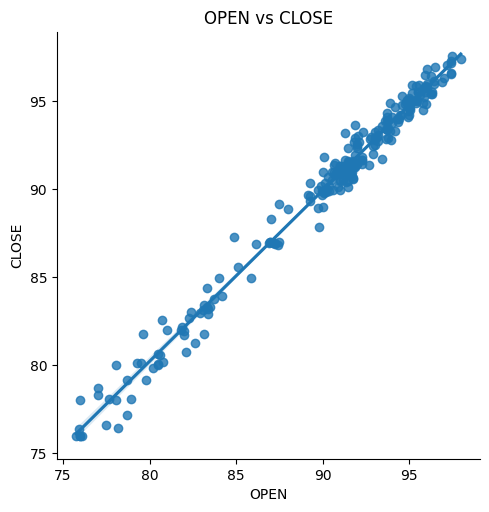

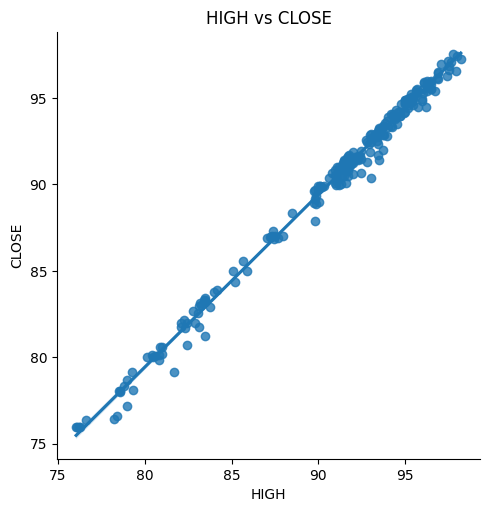

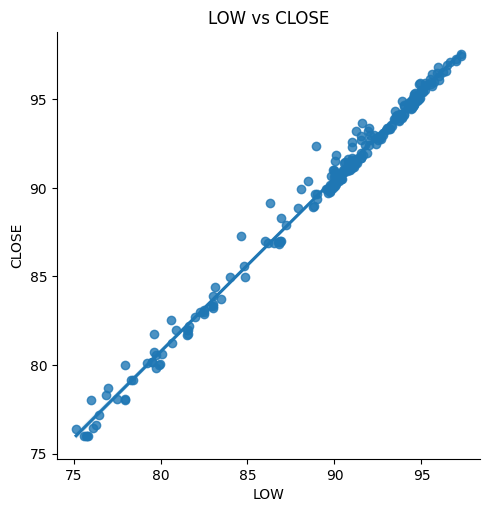

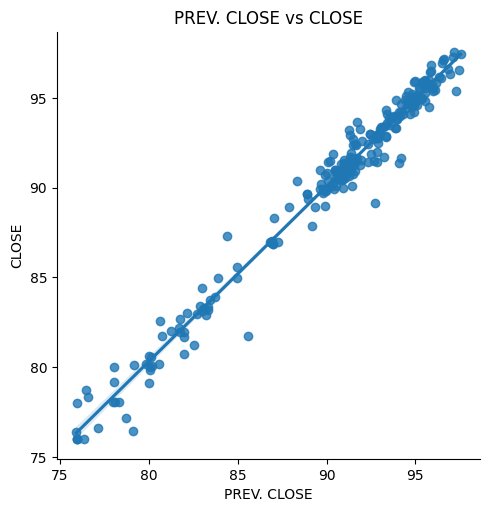

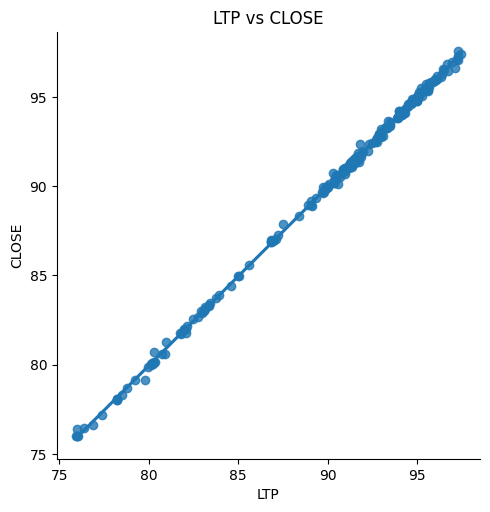

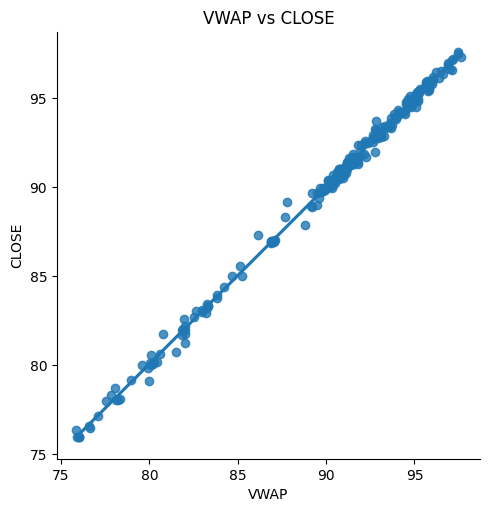

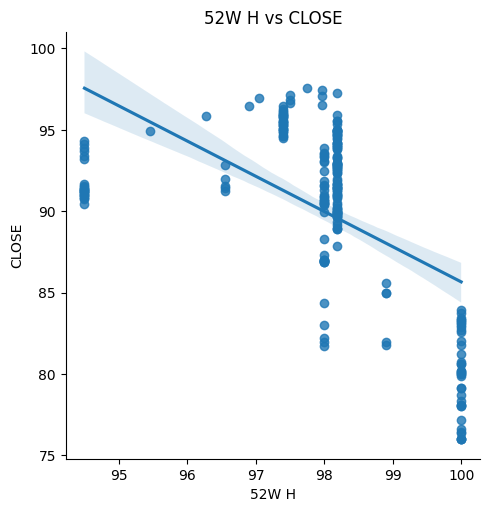

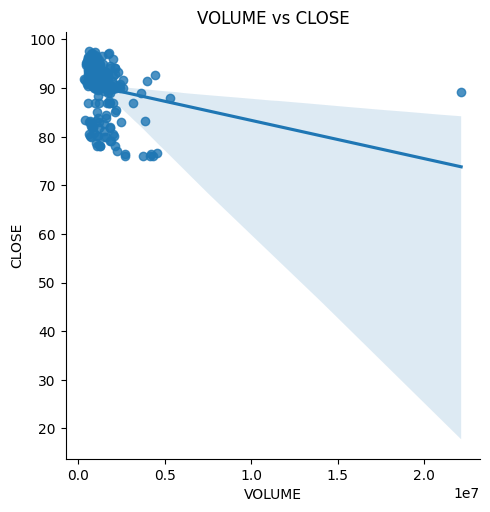

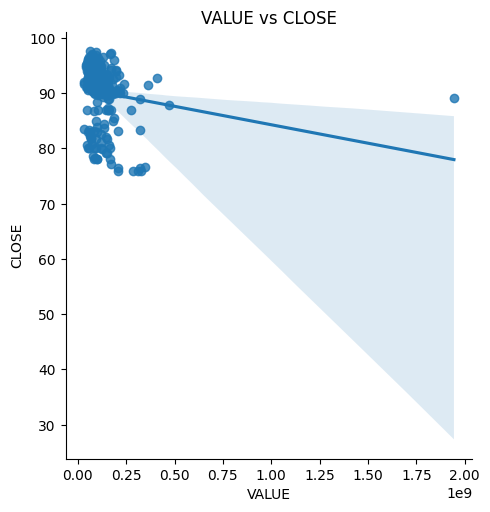

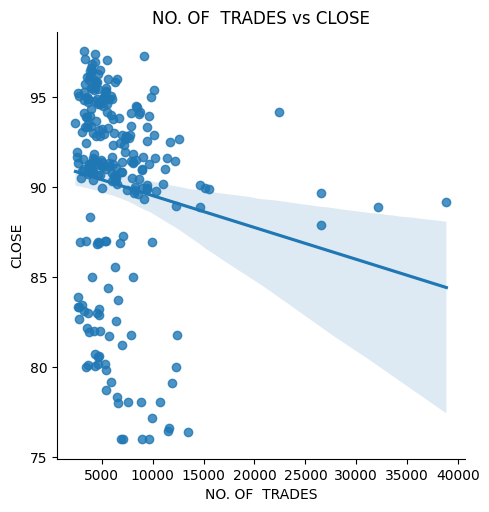

In [18]:
Target = 'CLOSE'

for col in columns:
    sns.lmplot(x=col,y=Target,data=PGINVIT)
    plt.title(f'{col} vs {Target}')
    plt.show()

## Test 2 --> Normality test

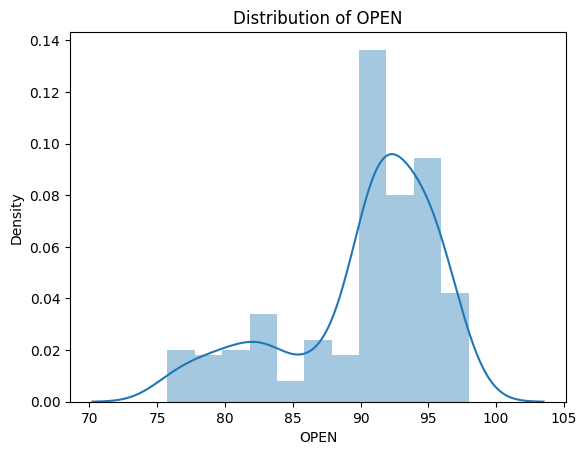

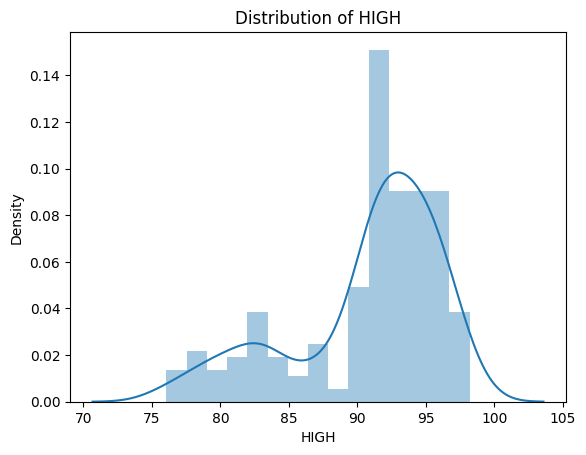

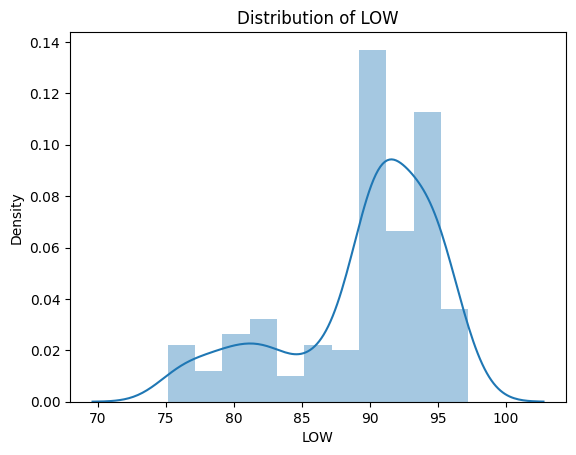

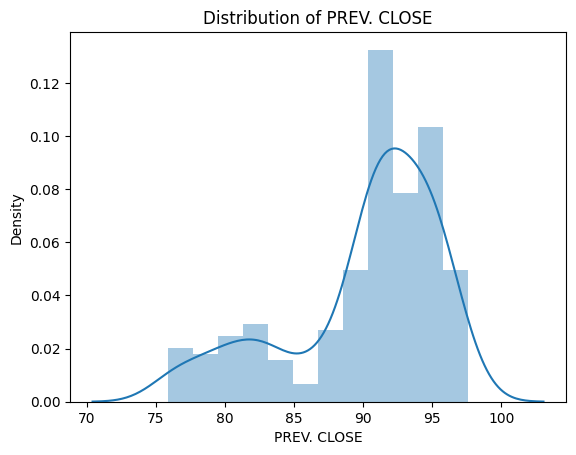

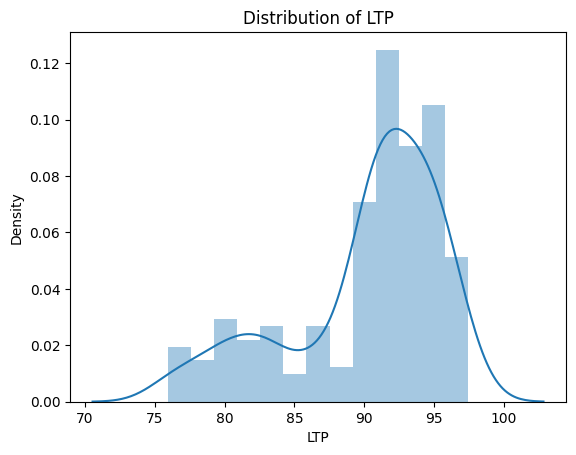

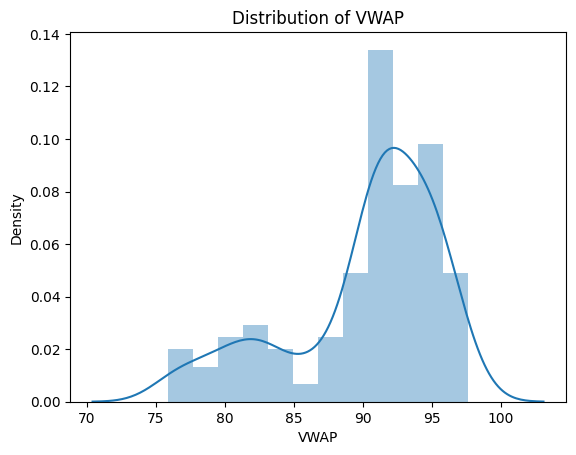

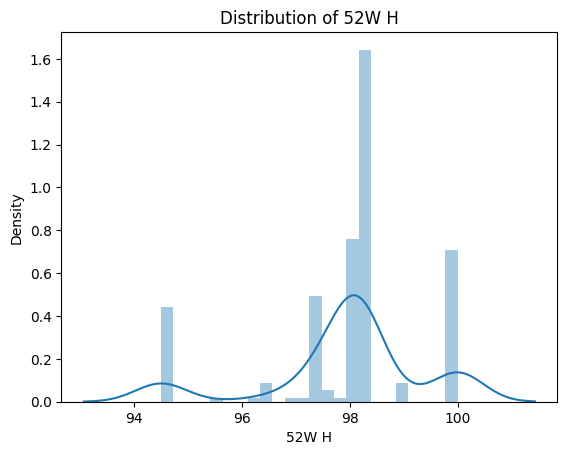

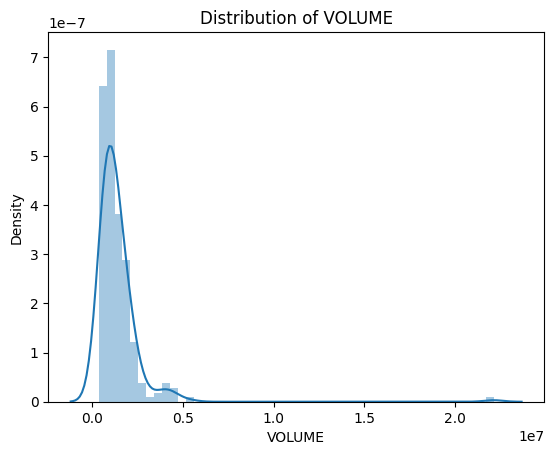

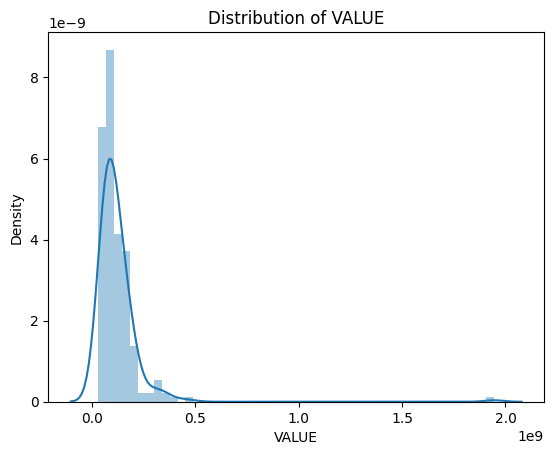

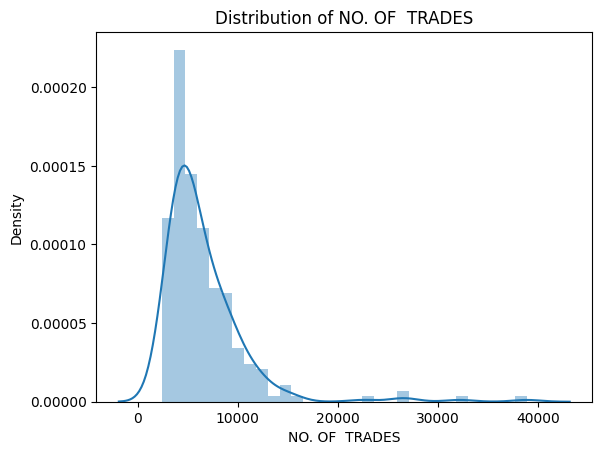

In [19]:
for col in columns:
    plt.figure()
    sns.distplot(PGINVIT[col])
    plt.title(f'Distribution of {col}')
    plt.show()

## TESt -->3 Multicollinerity test

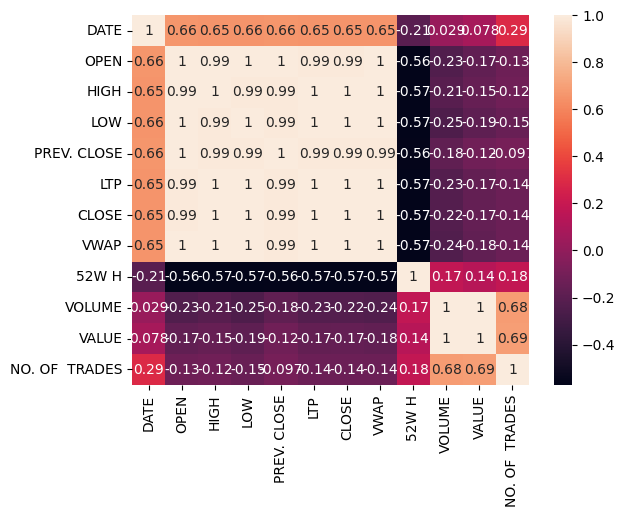

In [20]:
sns.heatmap(PGINVIT.corr(),annot=True)
plt.show()

## Test 4 --->AutoRegression(time based columns are not accepted)